In [1]:
# Plot time series of OSDMA8 exposure globally 

In [2]:
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

In [3]:
# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da


# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)

In [5]:
# === Concatenate ensemble members ===
def merge_ensembles(VAR_DIR, VAR, scenario, dates, time_mean=False, land_mask=False):
    """ land_filter=True allows for the land filter function to remove the ocean """
    ens = []

    for ens_num in range(1, 11):
        da = xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_{scenario}_{ens_num:02d}_{dates}.nc")
        if time_mean is True:
            da = da.mean("year")
        ens.append(da)

    new_da = xr.concat(ens, dim=xr.DataArray(np.arange(1, len(ens)+1), dims="ensemble", name="ensemble"))

    if land_mask is True:
        print("Filtering ocean")
        new_da = land_filter(new_da)

    return new_da

In [9]:
# === Path config ===
DIR = "/glade/work/awells/air_quality/CESM/ozone/exposure/"
VAR = "OSDMA8_global_population_weighted_exposure"

# === Main loop ===
arise = merge_ensembles(DIR, VAR, "ARISE", "2035-2069")
ssp245 = merge_ensembles(DIR, VAR, "SSP245", "2020-2069")

Text(0.5, 1.0, 'Difference in Global OSDMA8 exposure')

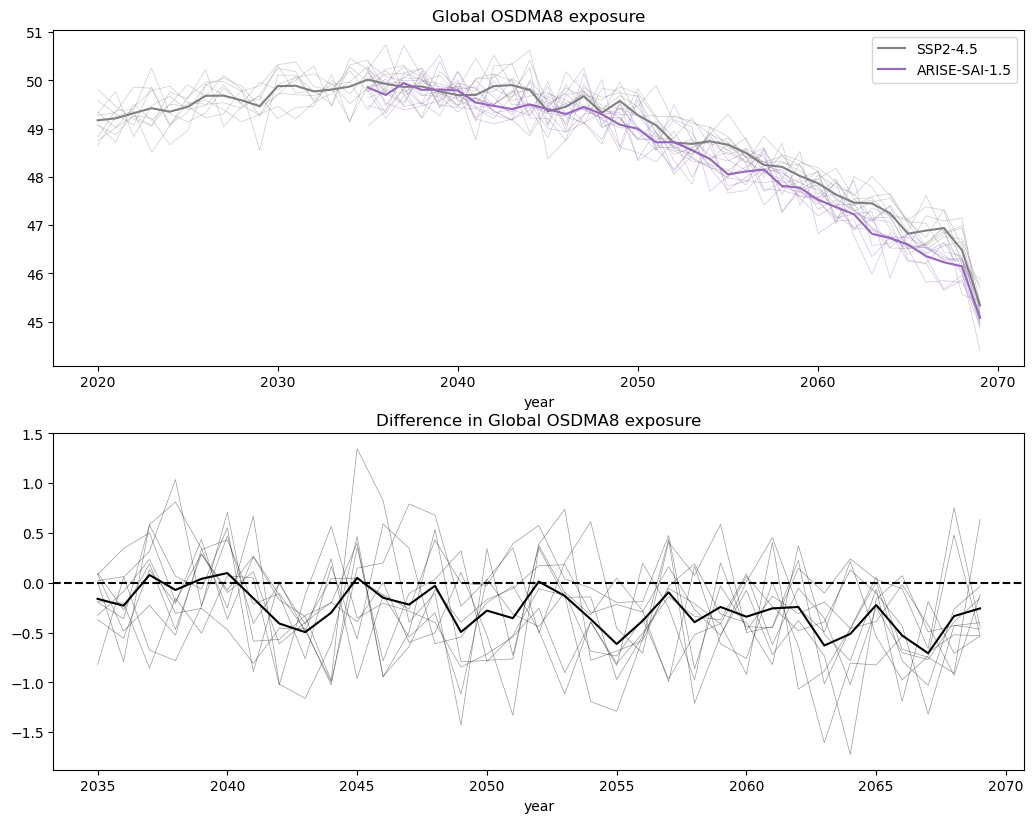

In [11]:
fig = plt.figure(figsize=autosize_figure(2, 1, xscale_factor=1.5))
gs = GridSpec(2, 1) # rows, columns

ax1 = fig.add_subplot(gs[0, 0])
for ens_num in range(1, 11):
    ssp245.sel(ensemble=ens_num).plot(color='grey', alpha=0.4, linewidth=0.5)
    arise.sel(ensemble=ens_num).plot(color='tab:purple', alpha=0.4, linewidth=0.5)
ssp245.mean("ensemble").plot(color='grey', label="SSP2-4.5")
arise.mean("ensemble").plot(color='tab:purple', label="ARISE-SAI-1.5")
plt.title("Global OSDMA8 exposure")
plt.legend()

ax2 = fig.add_subplot(gs[1, 0])
ssp245_time = ssp245.sel(year=slice(2035, 2069))
for ens_num in range(1, 11):
    (arise - ssp245_time).sel(ensemble=ens_num).plot(color='k', alpha=0.4, linewidth=0.5)
(arise - ssp245_time).mean("ensemble").plot(color='k')
plt.axhline(0, color='k', linestyle='--')
plt.title("Difference in Global OSDMA8 exposure")